In [2]:
print('Hello World')

Hello World


In [3]:
!nvidia-smi

Thu Aug 20 06:38:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:4A:00.0 Off |                    0 |
| N/A   33C    P8             33W /  350W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
import sys
import torch
from absl import app, flags
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
import torch


In [5]:
original_images=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/original_image_tensor.pt')
generated_images=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/generated_images_200_iteration1_python_inference_scipt.pt')
indices=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/distances/iteration1/lpips_minimum_indices.pt')# 

In [28]:
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [29]:
print(original_images.shape)
print(generated_images.shape)
print(indices.shape)

torch.Size([89, 3, 256, 256])
torch.Size([200, 3, 256, 256])
torch.Size([90, 2])


In [30]:
torchvision.utils.save_image(original_images,'/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/original_image_tensor.png')

In [22]:
original_images[-1].shape

torch.Size([3, 256, 256])

In [8]:
def image(x:torch.tensor):
    return x.permute([1,2,0]).detach().cpu()

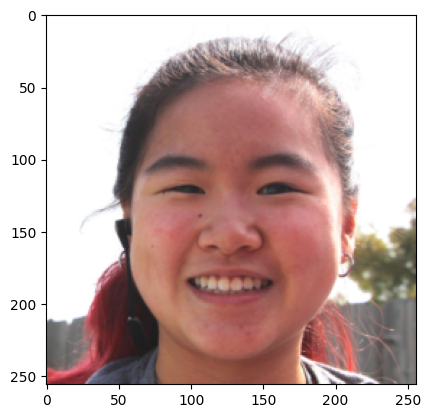

In [24]:
plt.imshow(image(original_images[-2]))

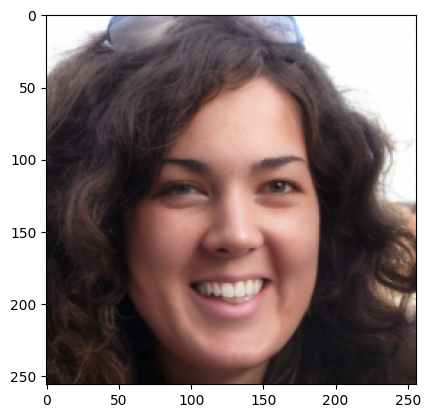

In [10]:
plt.imshow(image(generated_images[0]))

In [11]:
indices

tensor([[1.9600e+02, 3.7806e-01],
        [6.1000e+01, 5.5888e-02],
        [4.6000e+01, 5.2316e-02],
        [1.9600e+02, 5.3736e-02],
        [4.4000e+01, 3.5845e-01],
        [2.2000e+01, 5.0847e-02],
        [1.0400e+02, 4.6684e-02],
        [1.5500e+02, 4.6662e-02],
        [1.7300e+02, 3.8581e-02],
        [1.5100e+02, 4.4862e-02],
        [1.1000e+02, 4.8864e-02],
        [2.4000e+01, 4.6979e-02],
        [1.5000e+02, 5.1371e-02],
        [1.4400e+02, 5.7641e-02],
        [3.6000e+01, 5.2140e-02],
        [1.4000e+02, 5.8391e-02],
        [8.7000e+01, 5.3181e-02],
        [1.3000e+01, 2.8251e-01],
        [1.6300e+02, 3.7037e-02],
        [1.3800e+02, 5.4299e-02],
        [1.8400e+02, 4.0962e-02],
        [1.6600e+02, 6.8300e-02],
        [3.0000e+01, 5.2632e-02],
        [1.5000e+01, 5.4164e-02],
        [1.9900e+02, 2.6225e-01],
        [1.0300e+02, 4.4484e-02],
        [6.7000e+01, 5.5416e-02],
        [5.3000e+01, 4.1268e-02],
        [3.8000e+01, 2.6317e-01],
        [5.000

In [12]:
indexes=torch.argsort(indices[:,1])

In [13]:
generated_image_index=indices[indexes]

In [14]:
generated_image_index

tensor([[1.8500e+02, 2.1919e-02],
        [6.9000e+01, 3.0830e-02],
        [3.8000e+01, 3.0948e-02],
        [1.6300e+02, 3.7037e-02],
        [3.0000e+00, 3.8367e-02],
        [5.2000e+01, 3.8576e-02],
        [1.7300e+02, 3.8581e-02],
        [1.6800e+02, 3.9613e-02],
        [1.8400e+02, 4.0962e-02],
        [1.5400e+02, 4.1183e-02],
        [5.3000e+01, 4.1268e-02],
        [1.8100e+02, 4.1865e-02],
        [1.9000e+01, 4.3124e-02],
        [1.9500e+02, 4.3182e-02],
        [1.3700e+02, 4.3210e-02],
        [1.7000e+02, 4.3239e-02],
        [8.1000e+01, 4.3618e-02],
        [5.7000e+01, 4.3729e-02],
        [1.2900e+02, 4.4046e-02],
        [1.0300e+02, 4.4484e-02],
        [1.9800e+02, 4.4720e-02],
        [1.5100e+02, 4.4862e-02],
        [1.9900e+02, 4.5205e-02],
        [1.7900e+02, 4.5449e-02],
        [1.2300e+02, 4.6598e-02],
        [1.5500e+02, 4.6662e-02],
        [1.0400e+02, 4.6684e-02],
        [2.4000e+01, 4.6979e-02],
        [2.0000e+00, 4.6983e-02],
        [1.620

In [15]:
closest_generated_image=generated_images[generated_image_index[:,0].long()]

In [16]:
closest_generated_image.shape

torch.Size([90, 3, 256, 256])

In [19]:
generated_image_1=closest_generated_image[1]
generated_image_1.shape

torch.Size([3, 256, 256])

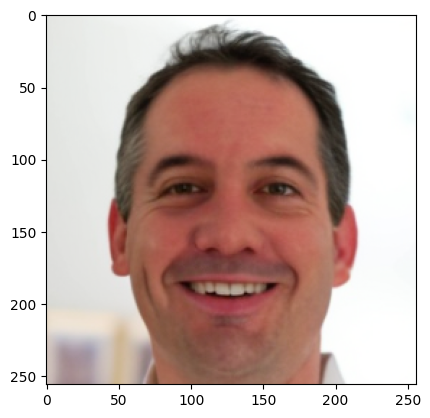

In [20]:
plt.imshow(image(generated_image_1))

In [33]:
!python /home/saurabhg/SFU_research_internship/examples/images/LATENT_GENERATION/inference.py

/home/saurabhg/flow_env/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
I0813 10:07:21.430278 125474363049408 _client.py:1025] HTTP Request: HEAD https://huggingface.co/stabilityai/sd-vae-ft-mse/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
W0813 10:07:21.430948 125474363049408 _http.py:953] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
I0813 10:07:21.443528 125474363049408 _client.py:1025] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stabilityai/sd-vae-ft-mse/31f26fdeee1355a5c34592e401dd41e45d25a493/config.json "HTTP/1.1 200 OK"
I0813 10:07:21.519490 125474363049408 _client.py:1025] HTTP Request: HEAD https://huggingface.co/stabilityai/sd-vae-ft-mse/resolve/31f

In [2]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py

Setting up LPIPS VGG...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
Calculating distances using chunked inner loop...
100%|██████████████████████████████████████████| 89/89 [04:27<00:00,  3.00s/it]
Done


In [ ]:
x=torch.rand((1000,3,256,256))
x_sliced=s[]

tensor([[2.9000e+01, 9.6276e-04],
        [1.0000e+00, 9.4137e-04],
        [7.6000e+01, 1.3218e-03],
        ...,
        [6.1000e+01, 1.1761e-03],
        [4.1000e+01, 9.1275e-04],
        [0.0000e+00, 1.1465e-03]], device='cuda:0')

In [9]:
indices.to(torch.device('cpu'))

tensor([[2.9000e+01, 9.6276e-04],
        [1.0000e+00, 9.4137e-04],
        [7.6000e+01, 1.3218e-03],
        ...,
        [6.1000e+01, 1.1761e-03],
        [4.1000e+01, 9.1275e-04],
        [0.0000e+00, 1.1465e-03]])

In [10]:
indices[:,0]

tensor([29.,  1., 76., 30., 42., 26., 92., 29., 83., 67., 82.,  8., 96., 28.,
        84., 15., 80., 84., 78., 51., 84., 47., 20., 94.,  3., 53., 42., 33.,
        52., 10., 97., 76., 61., 42., 47., 47., 24., 16., 94., 47., 82., 43.,
        61., 80., 94., 81., 47., 31., 62., 25., 22., 14., 84., 25., 17., 45.,
        29., 20., 88., 51., 64., 22., 33., 57., 31., 19., 44., 79., 36., 29.,
        64., 86., 29., 92., 83., 58., 30., 16.,  2., 80., 65., 70., 36., 81.,
        51., 16., 13.,  5., 67.,  7., 94., 40., 60., 45.,  7., 21., 47., 92.,
        19., 41., 34., 22., 66., 21., 81., 41.,  1., 67., 45., 31., 43., 96.,
        12., 12., 49.,  4., 53., 82., 55.,  0., 38., 48., 25., 31., 25., 80.,
        41., 33., 57., 84., 15., 74., 57., 69., 92., 34., 29., 21., 69., 16.,
        33., 43., 34., 46., 74., 88., 55., 92.,  9., 99., 50., 51., 45., 41.,
        29., 80., 86., 88., 45., 64., 92., 29., 41., 69., 28., 71., 16., 69.,
        39., 80., 37.,  8., 33., 40., 48., 94., 29., 51., 67., 7

In [11]:
out=torch.unique(indices[:,0],return_counts=True)
out=torch.stack((out[0],out[1]),dim=1)
out.shape
indices=torch.argsort(out[:,-1])
out=out[indices]
out

tensor([[56.,  1.],
        [68.,  1.],
        [85.,  1.],
        [ 6.,  2.],
        [10.,  2.],
        [23.,  2.],
        [26.,  2.],
        [35.,  2.],
        [72.,  2.],
        [87.,  2.],
        [32.,  3.],
        [59.,  3.],
        [63.,  3.],
        [65.,  3.],
        [27.,  4.],
        [34.,  4.],
        [66.,  4.],
        [71.,  4.],
        [75.,  4.],
        [77.,  4.],
        [78.,  4.],
        [91.,  4.],
        [99.,  4.],
        [ 4.,  5.],
        [14.,  5.],
        [52.,  5.],
        [54.,  5.],
        [73.,  5.],
        [81.,  5.],
        [83.,  5.],
        [95.,  5.],
        [98.,  5.],
        [ 9.,  6.],
        [21.,  6.],
        [37.,  6.],
        [90.,  6.],
        [ 5.,  7.],
        [ 8.,  7.],
        [11.,  7.],
        [36.,  7.],
        [46.,  7.],
        [50.,  7.],
        [58.,  7.],
        [70.,  7.],
        [76.,  7.],
        [86.,  7.],
        [ 1.,  8.],
        [ 3.,  8.],
        [22.,  8.],
        [38.,  8.],


<BarContainer object of 100 artists>

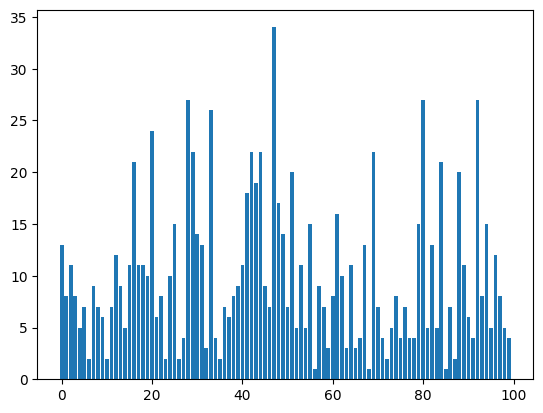

In [12]:
plt.bar(out[:,0].tolist(),out[:,1].tolist())

In [13]:
generated_images_sorted_by_frequency=generated_images[out[:,0].long()]

In [76]:
torchvision.utils.save_image(generated_images_sorted_by_frequency,'/home/saurabhg/scratch/CIFAR10/flow_outputs/icfm/distances/iteration4/generated_images_sorted_through_frequency.png')

In [95]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py

In [96]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py

^C
Traceback (most recent call last):
  File "/home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py", line 3, in <module>
    import lpips
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/__init__.py", line 11, in <module>
    from lpips.lpips import *
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/lpips.py", line 9, in <module>
    from . import pretrained_networks as pn
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/pretrained_networks.py", line 3, in <module>
    from torchvision import models as tv
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/__init__.py", line 10, in <module>
    from torchvision import _meta_registrations, datasets, io, models, ops, transforms, utils  # usort:skip
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/__init__.py", line 17, in <module>
    from . import detection, optical_flow, quantization, segmentation, vide

In [16]:
sorted_distance=torch.sort(indices[:,1])
sorted_distances_indices=sorted_distance[1]


In [17]:
orignal_images=torch.tile(original_images,(10,1,1,1))

In [18]:
closest_original_images=original_images[indices[:,0].long()]

In [ ]:
compare_image=torch.stack((generated_images,closest_original_images),dim=-1)

In [20]:
compare_image=compare_image[sorted_distances_indices].permute([0,4,1,2,3]).reshape(-1,3,32,32)


In [98]:
compare_image.shape

torch.Size([200, 3, 32, 32])

In [21]:
torchvision.utils.save_image(compare_image,'/home/saurabhg/scratch/flow_outputs/icfm/distances/iteration2/compare_images_sorted_distance.png',nrow=2)

In [97]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/Analysis.py

Generating 10000 images in batches of 100 on cuda...
Traceback (most recent call last):
  File "/home/saurabhg/SFU_research_internship/examples/images/cifar10/Analysis.py", line 66, in <module>
    app.run(inference)
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/absl/app.py", line 410, in run
    _run_main(main, args)
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/absl/app.py", line 355, in _run_main
    sys.exit(main(argv))
  File "/home/saurabhg/SFU_research_internship/examples/images/cifar10/Analysis.py", line 63, in inference
    original_dataset = get_original_image(100).cpu()
  File "/home/saurabhg/SFU_research_internship/examples/images/cifar10/utils_cifar.py", line 135, in get_original_image
    dataset=torchvision.datasets.CIFAR10(
  File "/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/datasets/cifar.py", line 69, in __init__
    raise RuntimeError("Dataset not found or corrupted. You can use download=True to download it")
Runtime

In [102]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py

In [38]:
torchvision.utils.save_image(generated_images,'/home/saurabhg/scratch/flow_outputs/icfm/generated_images/iteration3_200_images_generated.png',nrow=10)

In [50]:
class Cosine_Similarity:
    def __init__(self,image1_path,image2_path):
        device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
        self.image1_path=image1_path
        self.image2_path=image2_path
    def model(self):
        weights=torchvision.models.ViT_H_14_Weights.DEFAULT
        self.model=torchvision.models.vit_h_14(weights=weights)
    def process_image(self,image_path):
        image=torch.load(self.image1_path)
        transform=torchvision.transforms.Compose(
            [
                torchvision.transforms.Resize((518, 518), interpolation=InterpolationMode.BICUBIC),
                torchvision.transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

            ]
        )
        return transform(image)
    def get_emb(self):

        img1,img2=self.process_image(self.image1_path),self.process_image(self.image2_path)
        emb1,emb2=self.model(img1),self.model(img2)
        return emb1.detach().cpu(),emb2.detach().cpu()
    def score(self):
        emb1,emb2=self.get_emb()
        scores=torch.nn.funnctional.cosine_similarity(emb1,emb2)
        return scores.numpy().tolist()

In [52]:
cos_obj=Cosine_Similarity('/home/saurabhg/scratch/cifar10_data/image_tensor/original_image_100.pt','/home/saurabhg/scratch/flow_outputs/icfm/image_tensor/generated_ICFM_images_step_90000.pt')


In [ ]:
cos_obj.model()

Downloading: "https://download.pytorch.org/models/vit_h_14_swag-80465313.pth" to /tmp/cache/torch/hub/checkpoints/vit_h_14_swag-80465313.pth
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.36G/2.36G [00:52<00:00, 48.7MB/s]


In [56]:
cos_obj.score()

: 

: 

: 

In [1]:
print('Hello World')

Hello World


##How can I count the frequencies of the images generated in the given dataset..##
##how I would do? I would look it through my eye and see if it is same or not,now how does model will do it ,well we can use lpips model which will give distnace now as I move through the generated dataset i compare it with original dataset using lpips evaluation get the minimum and assign that particular image to it, now I can do one thing evrerytime a new image is encountered in the genereated dataset and I assign an image from the original dataset and make the frequency one, now when the next time an image in encountered I check it with the original images , get the new minimum and if this minimum distance is within the threshold of 

In [ ]:
def count_frequency(generated_images,original_images):
    # indices=calculate_lpips_modes_way2(generated_images,original_images)
    indices=torch.load('/home/saurabhg/scratch/CIFAR10/flow_outputs/icfm/distances/iteration4/lpips_way_2_minimum_indices.pt')
    indices=indices.to(torch.device('cpu'))
    print(indices.shape)
    out=torch.unique(indices[:,0],return_counts=True)
    print(out[0].shape,out[1].shape)
    out=torch.stack((out[0],out[1]),dim=-1)
    print(out.shape)
    indexes=torch.argsort(out[:,-1])
    out=out[indexes]
    print(out.shape)
    generated_images_sorted_by_frequency=original_images[out[:,0].long()]
    print(generated_images.shape)
    torchvision.utils.save_image(generated_images_sorted_by_frequency,'/home/saurabhg/scratch/CIFAR10/flow_outputs/icfm/distances/iteration4/1000_generated_images_sorted_through_frequency_script.png')
    return out

In [87]:
count_frequency(generated_images,original_images)

torch.Size([1000, 2])
torch.Size([1100]) torch.Size([1100])
torch.Size([1100, 2])
torch.Size([1100, 2])
torch.Size([1000, 3, 32, 32])


tensor([[1.3932e-03, 1.0000e+00],
        [1.3727e-03, 1.0000e+00],
        [1.3733e-03, 1.0000e+00],
        ...,
        [2.8000e+01, 2.7000e+01],
        [8.0000e+01, 2.7000e+01],
        [4.7000e+01, 3.4000e+01]])

In [93]:
!ls -lh /scratch/saurabhg/flow_outputs/icfm/

total 32K
drwxr-x--- 2 saurabhg saurabhg 0 Aug 11 12:57 distances


In [7]:
device

NameError: name 'device' is not defined

In [6]:
from diffusers.models import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse")


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/home/saurabhg/flow_env/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

In [7]:
vae=vae.to(device)


In [9]:
import torchvision
from torchvision import transforms
from PIL import Image

In [10]:
from torch.utils.data import DataLoader

In [11]:
class FlatImageDataset:
    def __init__(self,folder_path:str,image_size:int=256):
        self.folder_path=folder_path
        self.image_files=[f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
        self.image_size=image_size
        self.transform=transforms.Compose([
            transforms.Resize((self.image_size,self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])        
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self,idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        return self.transform(image)


In [12]:
dataset=FlatImageDataset('/home/saurabhg/scratch/LATENT_DATASET/img')

In [15]:
dataloader=DataLoader(
    dataset=dataset,
    batch_size=89,
    shuffle=False,
    num_workers=2,
    pin_memory=True

)

In [16]:
images = next(iter(dataloader))
print(f"Total Images Found: {len(dataset)}")
print(f"Batch Tensor Shape: {images.shape}")

Total Images Found: 89
Batch Tensor Shape: torch.Size([89, 3, 256, 256])


In [18]:
out_normalized=images[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.8901961].


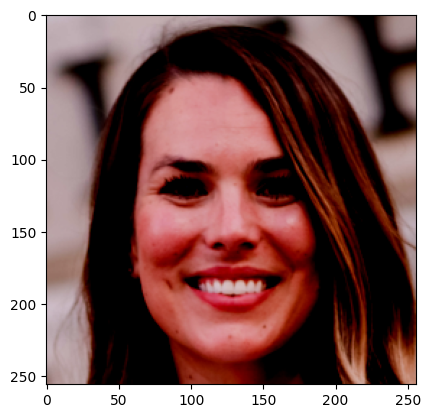

In [19]:
plt.imshow(out_normalized.squeeze(dim=0).permute([1,2,0]).detach().cpu())

In [20]:
out_unnormalized=out_normalized*0.5+0.5

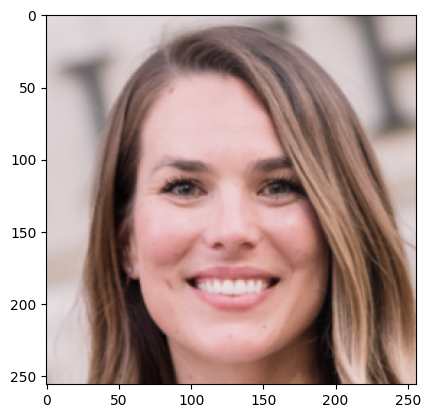

In [21]:
plt.imshow(out_unnormalized.squeeze(dim=0).permute([1,2,0]).detach().cpu())

In [47]:
dummy_input=torch.randn((1,3,256,256)).to(device)

In [48]:
plt.imshow(out.squeeze(dim=0).permute([1,2,0]).detach().cpu())

AttributeError: 'Image' object has no attribute 'squeeze'

In [93]:
out_unnormalized=out_unnormalized.unsqueeze(dim=0)
out_unnormalized=out_unnormalized.to(device)

In [105]:
out_unnormalized.shape

torch.Size([1, 3, 256, 256])

In [106]:
encoded=vae.encode(out_unnormalized).latent_dist
latent=encoded.sample()
print(latent.shape)
scaled_latent=latent*vae.config.scaling_factor
print(scaled_latent.shape)


torch.Size([1, 4, 32, 32])
torch.Size([1, 4, 32, 32])


In [107]:
scaled_latents=scaled_latent/(vae.config.scaling_factor)
print(scaled_latent.shape)
decoded_image=vae.decode(scaled_latents)
generated_image=decoded_image.sample
print(generated_image.shape)

torch.Size([1, 4, 32, 32])
torch.Size([1, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19178528..0.97797376].


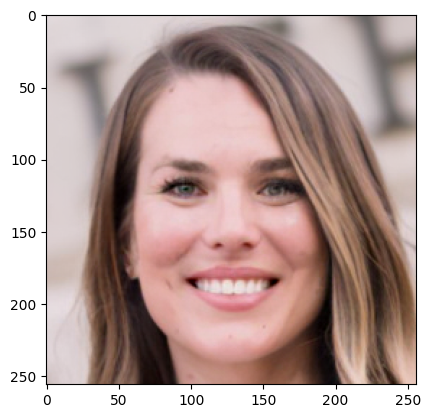

In [98]:
plt.imshow(generated_image.squeeze(dim=0).permute([1,2,0]).detach().cpu())

In [26]:
decoded=vae.decoder(encoded)
decoded.shape


RuntimeError: Given groups=1, weight of size [512, 4, 3, 3], expected input[1, 8, 32, 32] to have 4 channels, but got 8 channels instead

In [6]:
distribution_1000=torch.load('/home/saurabhg/scratch/CIFAR10/flow_outputs/icfm/distances/iteration4/frequency_distribution.pt')
distribution_10000=torch.load('/home/saurabhg/scratch/CIFAR10/flow_outputs/icfm/distances/iteration5/frequency_distribution.pt')

In [7]:
distribution_10000.shape

torch.Size([100, 2])

In [8]:
distribution_1000

tensor([[85.,  1.],
        [68.,  1.],
        [56.,  1.],
        [35.,  2.],
        [72.,  2.],
        [23.,  2.],
        [26.,  2.],
        [ 6.,  2.],
        [87.,  2.],
        [10.,  2.],
        [59.,  3.],
        [65.,  3.],
        [63.,  3.],
        [32.,  3.],
        [27.,  4.],
        [66.,  4.],
        [34.,  4.],
        [71.,  4.],
        [77.,  4.],
        [75.,  4.],
        [78.,  4.],
        [91.,  4.],
        [99.,  4.],
        [73.,  5.],
        [81.,  5.],
        [14.,  5.],
        [83.,  5.],
        [54.,  5.],
        [52.,  5.],
        [ 4.,  5.],
        [95.,  5.],
        [98.,  5.],
        [37.,  6.],
        [21.,  6.],
        [ 9.,  6.],
        [90.,  6.],
        [70.,  7.],
        [50.,  7.],
        [58.,  7.],
        [76.,  7.],
        [86.,  7.],
        [46.,  7.],
        [ 5.,  7.],
        [ 8.,  7.],
        [11.,  7.],
        [36.,  7.],
        [ 1.,  8.],
        [97.,  8.],
        [60.,  8.],
        [ 3.,  8.],


In [12]:
distribution_10000

tensor([[ 56.,   4.],
        [ 85.,  24.],
        [ 32.,  28.],
        [ 72.,  30.],
        [ 59.,  31.],
        [  6.,  31.],
        [ 68.,  33.],
        [ 34.,  33.],
        [ 27.,  34.],
        [ 23.,  36.],
        [ 87.,  36.],
        [ 35.,  39.],
        [ 65.,  39.],
        [ 22.,  40.],
        [ 26.,  42.],
        [ 21.,  43.],
        [ 83.,  43.],
        [ 46.,  44.],
        [ 99.,  44.],
        [  5.,  44.],
        [  9.,  46.],
        [ 73.,  46.],
        [ 71.,  48.],
        [ 78.,  48.],
        [ 95.,  51.],
        [ 38.,  53.],
        [ 66.,  53.],
        [ 52.,  54.],
        [  8.,  57.],
        [ 14.,  58.],
        [ 10.,  59.],
        [ 81.,  61.],
        [ 55.,  62.],
        [ 13.,  62.],
        [ 63.,  64.],
        [  3.,  66.],
        [ 53.,  67.],
        [ 45.,  67.],
        [ 74.,  67.],
        [  4.,  71.],
        [ 36.,  71.],
        [ 39.,  71.],
        [ 98.,  71.],
        [ 11.,  72.],
        [ 75.,  77.],
        [ 

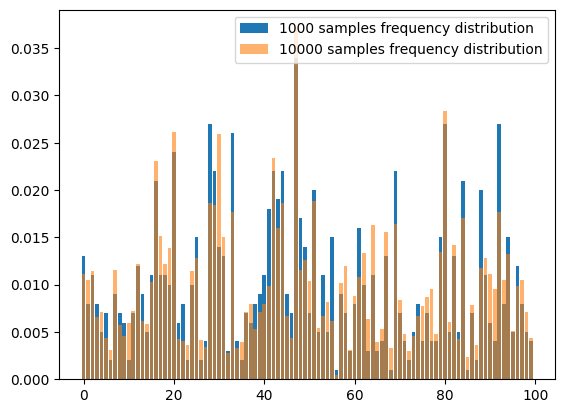

In [10]:
plt.figure()
plt.bar((distribution_1000[:,0]).tolist(),(distribution_1000[:,1]/1000).tolist(),label='1000 samples frequency distribution')
plt.bar((distribution_10000[:,0]).tolist(),(distribution_10000[:,1]/10000).tolist(),label='10000 samples frequency distribution',alpha=0.6)
plt.legend()
plt.show()

In [ ]:
def count_frequency(indices,original_images,return_frequency=False):
    # indices=calculate_lpips_modes_way2(generated_images,original_images)
    indices=indices.to(torch.device('cpu'))
    out=torch.unique(indices[:,0],return_counts=True)
    out=torch.stack((out[0],out[1]),dim=-1)
    indexes=torch.argsort(out[:,-1])
    out=out[indexes]
    generated_images_sorted_by_frequency=original_images[out[:,0].long()]
    return generated_images_sorted_by_frequency

In [108]:
!python /home/saurabhg/SFU_research_internship/examples/images/LATENT_GENERATION/vae_train2.py

In [16]:
generated_images=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/generated_images_10_iteration1_python_inference_scipt.pt')

In [21]:
generated_image=generated_images[-1]

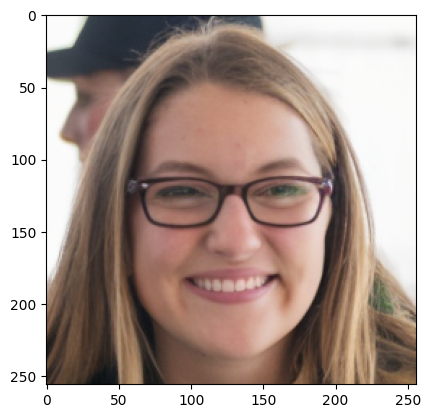

In [22]:
plt.imshow(generated_image.permute([1,2,0]).detach().cpu())

In [17]:
!python /home/saurabhg/SFU_research_internship/examples/images/LATENT_GENERATION/inference.py

/home/saurabhg/flow_env/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
I0812 15:25:33.131885 137063368254912 _client.py:1025] HTTP Request: HEAD https://huggingface.co/stabilityai/sd-vae-ft-mse/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
I0812 15:25:33.153542 137063368254912 _client.py:1025] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/stabilityai/sd-vae-ft-mse/31f26fdeee1355a5c34592e401dd41e45d25a493/config.json "HTTP/1.1 200 OK"
I0812 15:25:33.253262 137063368254912 _client.py:1025] HTTP Request: HEAD https://huggingface.co/stabilityai/sd-vae-ft-mse/resolve/31f26fdeee1355a5c34592e401dd41e45d25a493/diffusion_pytorch_model.safetensors.index.json "HTTP/1.1 404 Not Found"
W0812 15:25:33.253833 137063368254912 _http.py:953] Warning: You are sending una

In [23]:
import torch
from torchvision import transforms
from PIL import Image
device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [24]:
class FlatImageDataset:
    def __init__(self,folder_path:str,image_size:int=256):
        self.folder_path=folder_path
        self.image_files=[f for f in os.listdir(folder_path) if f.lower().endswith('.png')]
        self.image_size=image_size
        self.transform=transforms.Compose([
            transforms.Resize((self.image_size,self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])        
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self,idx):
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        return self.transform(image)

In [25]:
dataset=FlatImageDataset('/home/saurabhg/scratch/LATENT_DATASET/img')
full_dataset_size=len(dataset)
dataloader=torch.utils.data.DataLoader(
    dataset=dataset,
    batch_size=full_dataset_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
dataset=next(iter(dataloader)).to(device)

In [26]:
torch.save(dataset*0.5+0.5,'/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/original_image_tensor.pt')

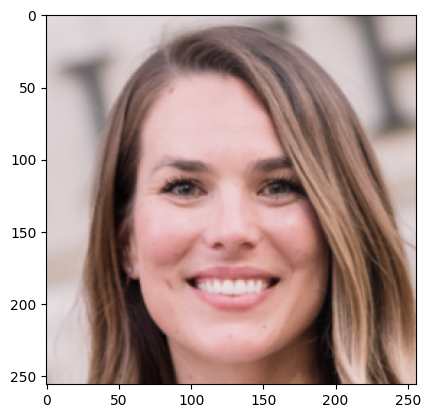

In [16]:
data=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/original_image_tensor.pt')
image=data[0]
plt.imshow(image.permute([1,2,0]).detach().cpu())

In [13]:
torchvision.utils.save_image(dataset,'/home/saurabhg/scratch/LATENT_DATASET/img/original_image.png',nrow=10)

In [16]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /tmp/cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|████████████████████████████████████████| 528M/528M [00:02<00:00, 234MB/s]
Loading model from: /home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/we

In [5]:
minimum_indices=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/distances/iteration3/lpips_minimum_indices.pt')


In [6]:
minimum_indices

tensor([[2.2000e+02, 3.7418e-02],
        [8.7500e+02, 5.5353e-02],
        [1.7700e+02, 5.2102e-02],
        [4.8500e+02, 5.3050e-02],
        [8.4000e+02, 4.3997e-02],
        [6.9800e+02, 5.0782e-02],
        [2.6800e+02, 4.6369e-02],
        [8.6800e+02, 4.5905e-02],
        [6.8000e+02, 3.8685e-02],
        [9.3500e+02, 4.4627e-02],
        [1.4400e+02, 4.8029e-02],
        [8.3600e+02, 4.6917e-02],
        [2.5400e+02, 5.0427e-02],
        [7.5400e+02, 5.6366e-02],
        [7.7800e+02, 5.2290e-02],
        [3.2300e+02, 5.8261e-02],
        [9.0000e+00, 5.2649e-02],
        [7.5500e+02, 3.5425e-02],
        [9.2300e+02, 3.7219e-02],
        [3.8900e+02, 5.3114e-02],
        [1.1600e+02, 4.0589e-02],
        [6.4600e+02, 6.7672e-02],
        [1.6200e+02, 5.2577e-02],
        [4.3500e+02, 5.2776e-02],
        [2.0600e+02, 4.4816e-02],
        [1.2000e+01, 4.4131e-02],
        [3.7900e+02, 5.5444e-02],
        [3.4600e+02, 4.0829e-02],
        [3.3000e+02, 3.2140e-02],
        [7.260

In [5]:
def image(image):
    return image.permute([1,2,0]).detach().cpu()
def kl_divergence(tensor1,tensor2,eps=1e-10):
    tensor1=torch.clamp(tensor1,min=eps)
    t2=torch.clamp(tensor2,min=eps)
    return torch.sum(tensor1*torch.log(tensor1/tensor2))


In [6]:
def plot_distribution(minimum_indices,k=2):
    minimum_indices=minimum_indices if isinstance(minimum_indices,torch.Tensor) else torch.load(minimum_indices)
    values=minimum_indices[:,1]
    values = minimum_indices[:, 1].detach().cpu()
    num_elements = values.shape[0]
    x_axis = torch.arange(0, num_elements, 1)
    mean_val = torch.mean(values).item()
    top_k = torch.topk(values, k)
    top_values = top_k.values.tolist()
    top_indices = top_k.indices.tolist()

    plt.figure(figsize=(12, 6))
    plt.bar(x_axis, values, color="skyblue", alpha=0.3)
    plt.axhline(mean_val, color="red", linestyle=':', label=f'Mean: {mean_val:.4f}')

    for rank, (idx, val) in enumerate(zip(top_indices, top_values)):
        x_offset = num_elements * 0.04 if rank % 2 == 0 else -num_elements * 0.12
        y_offset = val * 0.95
        
        plt.annotate(
            f'#{rank+1} (Idx {idx}): {val:.4f}',
            xy=(idx, val),
            xytext=(idx + x_offset, y_offset),
            arrowprops=dict(arrowstyle="->", color="black", connectionstyle="arc3,rad=.2"),
            fontsize=9,
            weight='bold'
        )
    plt.xlabel("Index")
    plt.ylabel("LPIPS Distance")
    plt.title("LPIPS Distribution - Top 5 Maximum Values Highlighted")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
indices=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/distances/iteration3/lpips_minimum_indices.pt')
indices_way_2=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/distances/iteration3/lpips_way_2_minimum_indices.pt')
original_images=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/original_image_tensor.pt')
generated_images=torch.load('/home/saurabhg/scratch/LATENT_DATASET/flow_outputs/icfm/image_tensor/generated_images_1000_iteration3_python_inference_scipt.pt')

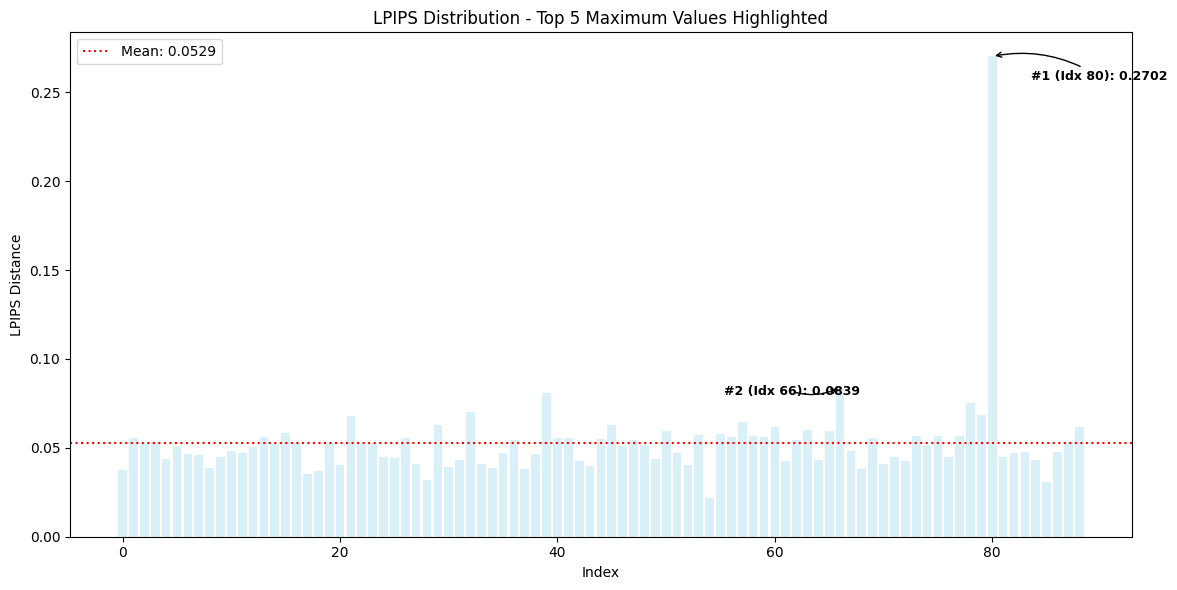

In [8]:
plot_distribution(indices)

In [9]:
def frequency_mask(minimum_indices_way1,threshold):
    minimum_indices_way1=minimum_indices_way1 if isinstance(minimum_indices_way1,torch.Tensor) else torch.load('minimum_indices_way_1')
    distance_values=minimum_indices_way1[:,1]
    mask=distance_values>threshold
    mask=(~mask.bool()).int()
    return mask

In [10]:
out=frequency_mask(indices,0.1)

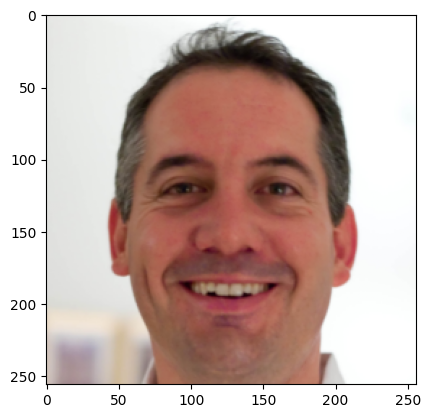

In [11]:
plt.imshow(image(original_images[80]))

In [12]:
indices_way_2

tensor([[6.0000e+00, 4.6788e-02],
        [1.7000e+01, 3.5442e-02],
        [7.0000e+00, 4.6767e-02],
        ...,
        [6.0000e+00, 4.6553e-02],
        [7.3000e+01, 5.6731e-02],
        [8.0000e+00, 3.9418e-02]], device='cuda:0')

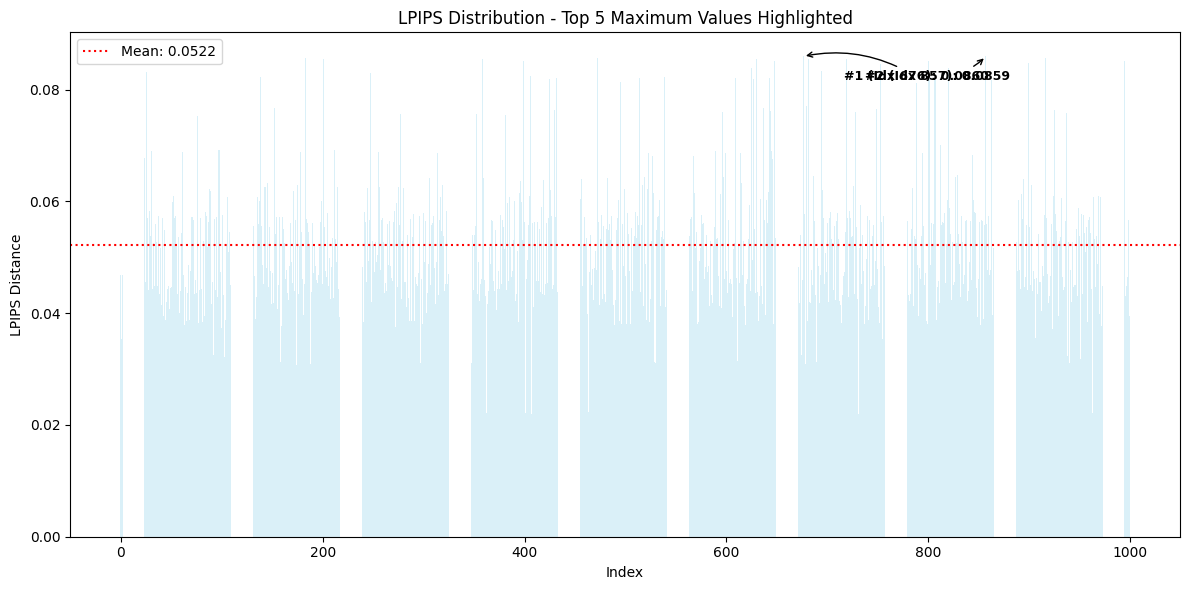

In [13]:
plot_distribution(indices_way_2)

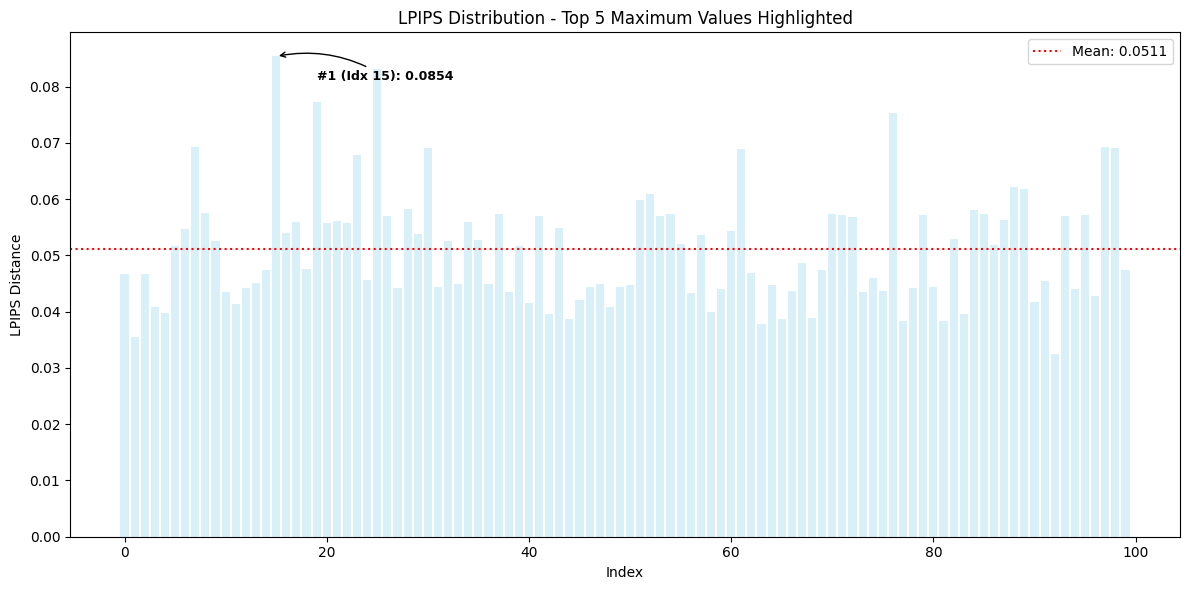

In [14]:
plot_distribution(indices_way_2[:100],k=1)

In [90]:
torch.topk(indices_way_2[:,1],k=50)

torch.return_types.topk(
values=tensor([0.0860, 0.0859, 0.0858, 0.0857, 0.0857, 0.0857, 0.0856, 0.0856, 0.0855,
        0.0855, 0.0855, 0.0854, 0.0854, 0.0854, 0.0851, 0.0851, 0.0851, 0.0851,
        0.0850, 0.0849, 0.0848, 0.0846, 0.0839, 0.0839, 0.0833, 0.0831, 0.0830,
        0.0827, 0.0825, 0.0825, 0.0823, 0.0823, 0.0823, 0.0823, 0.0822, 0.0822,
        0.0822, 0.0821, 0.0821, 0.0821, 0.0821, 0.0820, 0.0820, 0.0819, 0.0818,
        0.0817, 0.0813, 0.0813, 0.0808, 0.0772], device='cuda:0'),
indices=tensor([676, 857, 329, 183, 916, 882, 472, 719, 630, 201, 681, 358,  15, 775,
        399, 800, 994, 648, 668, 448, 899, 753, 820, 625, 694,  25, 247, 773,
        807, 406, 539, 667, 236, 434, 138, 432, 806, 344, 514, 643, 609, 425,
        627, 801, 863, 341, 495, 788, 332,  19], device='cuda:0'))

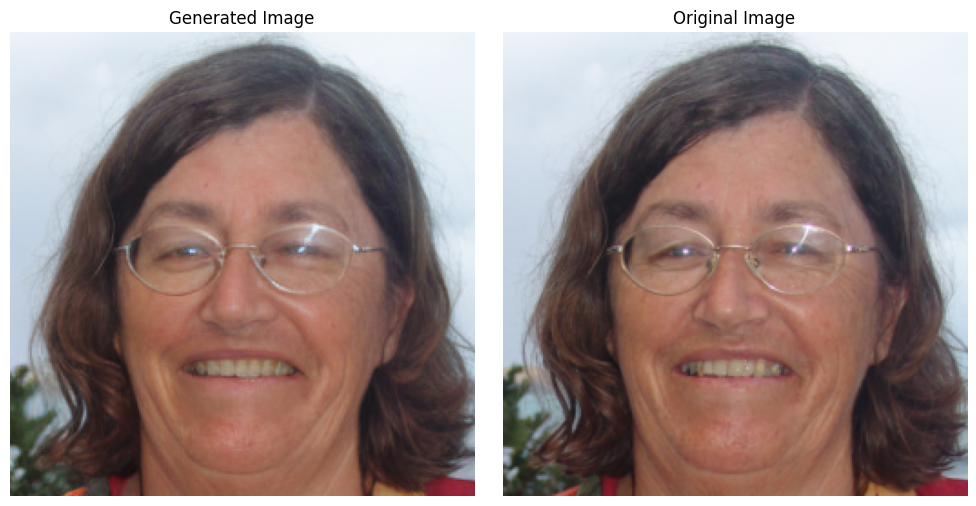

In [15]:
index=539
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image(generated_images[index]))
ax[0].set_title("Generated Image")
ax[0].axis("off")

ax[1].imshow(image(original_images[indices_way_2[:, 0][index].long()]))
ax[1].set_title("Original Image")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [16]:

def count_frequency(indices,generated_images,original_images,return_frequency=True):
    indices=torch.load(f'/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration{FLAGS.iteration}/lpips_way_2_minimum_indices.pt')
    indices=indices.to(torch.device('cpu'))
    out=torch.unique(indices[:,0],return_counts=True)
    out=torch.stack((out[0],out[1]),dim=-1)
    dummy_tensor=torch.stack((torch.arange(0,len(original_images),1),torch.zeros(len(original_images))),dim=1)
    row_indices,values=out[:,0],out[:,1]
    dummy_tensor[row_indices.long(),1]=values
    
    frequency_sorted_indexes=torch.argsort(dummy_tensor[:,1])
    out=dummy_tensor[frequency_sorted_indexes]
    generated_images_sorted_by_frequency=original_images[out[:,0].long()]
    torchvision.utils.save_image(generated_images_sorted_by_frequency,f'/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration{FLAGS.iteration}/10000_generated_images_sorted_through_frequency_script.png')
    torch.save(dummy_tensor,f'/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration{FLAGS.iteration}/frequency_distribution.pt')
    if return_frequency:
        return dummy_tensor

In [93]:
frequency_distribution=count_frequency(indices_way_2,generated_images,original_images)

NameError: name 'FLAGS' is not defined

In [ ]:
frequency_distribution

tensor([[ 0.,  2.],
        [ 1., 27.],
        [ 2.,  4.],
        [ 3.,  6.],
        [ 4.,  5.],
        [ 5.,  4.],
        [ 6., 13.],
        [ 7.,  8.],
        [ 8.,  8.],
        [ 9., 13.],
        [10.,  9.],
        [11.,  7.],
        [12.,  3.],
        [13., 16.],
        [14.,  6.],
        [15.,  2.],
        [16., 10.],
        [17.,  3.],
        [18., 19.],
        [19.,  7.],
        [20., 14.],
        [21.,  9.],
        [22., 27.],
        [23., 14.],
        [24.,  7.],
        [25., 19.],
        [26., 27.],
        [27., 15.],
        [28.,  6.],
        [29., 10.],
        [30., 11.],
        [31., 12.],
        [32.,  3.],
        [33., 31.],
        [34., 13.],
        [35., 13.],
        [36., 10.],
        [37.,  7.],
        [38., 32.],
        [39., 26.],
        [40.,  1.],
        [41., 15.],
        [42., 19.],
        [43.,  1.],
        [44.,  2.],
        [45.,  9.],
        [46., 18.],
        [47., 11.],
        [48., 18.],
        [49.,  6.],


In [ ]:
frequency_distribution

tensor([[ 0.,  2.],
        [ 1., 27.],
        [ 2.,  4.],
        [ 3.,  6.],
        [ 4.,  5.],
        [ 5.,  4.],
        [ 6., 13.],
        [ 7.,  8.],
        [ 8.,  8.],
        [ 9., 13.],
        [10.,  9.],
        [11.,  7.],
        [12.,  3.],
        [13., 16.],
        [14.,  6.],
        [15.,  2.],
        [16., 10.],
        [17.,  3.],
        [18., 19.],
        [19.,  7.],
        [20., 14.],
        [21.,  9.],
        [22., 27.],
        [23., 14.],
        [24.,  7.],
        [25., 19.],
        [26., 27.],
        [27., 15.],
        [28.,  6.],
        [29., 10.],
        [30., 11.],
        [31., 12.],
        [32.,  3.],
        [33., 31.],
        [34., 13.],
        [35., 13.],
        [36., 10.],
        [37.,  7.],
        [38., 32.],
        [39., 26.],
        [40.,  1.],
        [41., 15.],
        [42., 19.],
        [43.,  1.],
        [44.,  2.],
        [45.,  9.],
        [46., 18.],
        [47., 11.],
        [48., 18.],
        [49.,  6.],


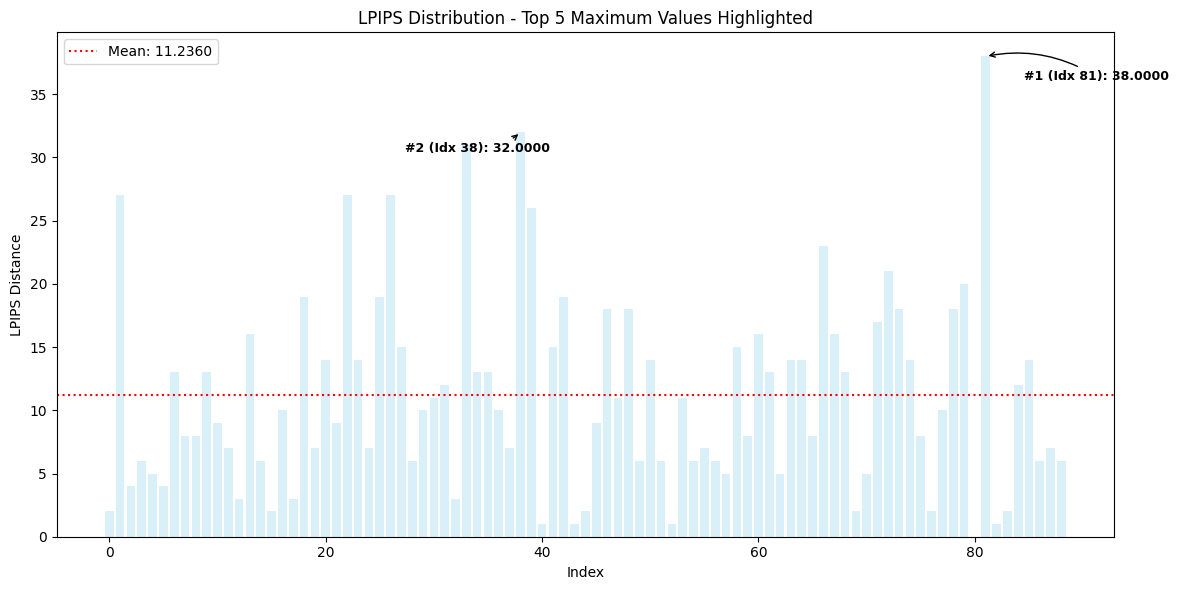

In [ ]:
plot_distribution(frequency_distribution)

In [94]:
frequency_sorted_indexes=torch.argsort(frequency_distribution[:,1])
out=frequency_distribution[frequency_sorted_indexes]
out

tensor([[17.,  0.],
        [11.,  0.],
        [ 2.,  1.],
        [55.,  1.],
        [82.,  1.],
        [78.,  1.],
        [68.,  2.],
        [69.,  2.],
        [29.,  2.],
        [64.,  2.],
        [74.,  2.],
        [21.,  3.],
        [25.,  3.],
        [60.,  3.],
        [98.,  3.],
        [86.,  3.],
        [37.,  4.],
        [38.,  4.],
        [66.,  4.],
        [54.,  4.],
        [80.,  4.],
        [72.,  4.],
        [ 5.,  4.],
        [16.,  4.],
        [76.,  4.],
        [96.,  4.],
        [13.,  4.],
        [84.,  5.],
        [42.,  5.],
        [39.,  5.],
        [35.,  5.],
        [ 6.,  5.],
        [24.,  5.],
        [87.,  6.],
        [41.,  6.],
        [97.,  6.],
        [50.,  6.],
        [65.,  7.],
        [32.,  7.],
        [89.,  7.],
        [28.,  7.],
        [10.,  7.],
        [ 9.,  7.],
        [ 3.,  7.],
        [79.,  7.],
        [59.,  7.],
        [53.,  8.],
        [62.,  8.],
        [ 4.,  8.],
        [81.,  8.],


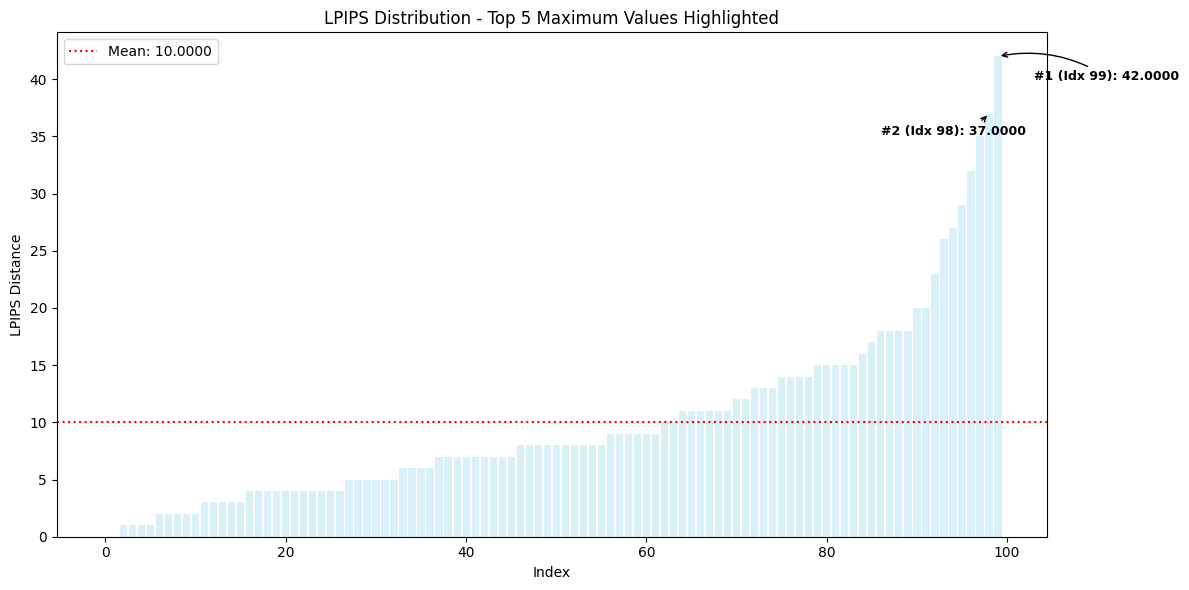

In [95]:
plot_distribution(out)

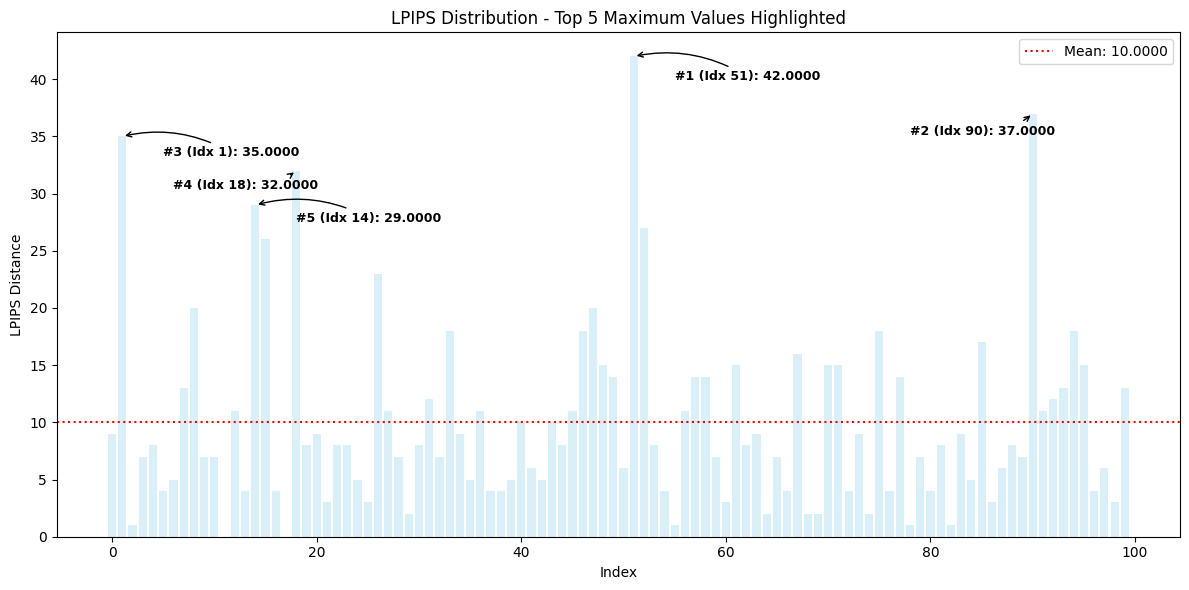

In [96]:
plot_distribution(frequency_distribution,k=5)

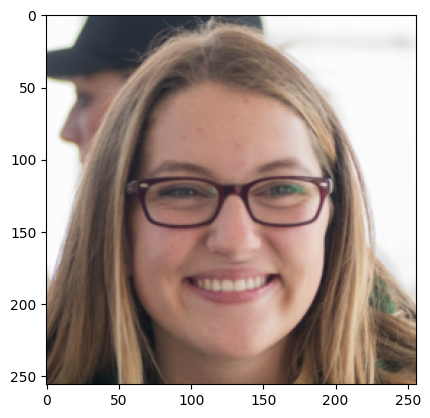

In [97]:
plt.imshow(image(original_images[38]))

<BarContainer object of 100 artists>

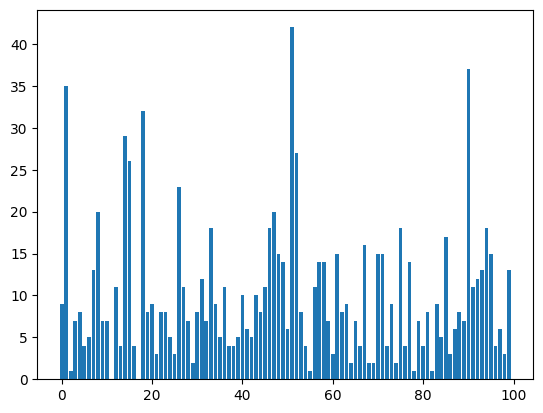

In [98]:
plt.bar((frequency_distribution[:,0].detach().cpu()),frequency_distribution[:,1].detach().cpu())

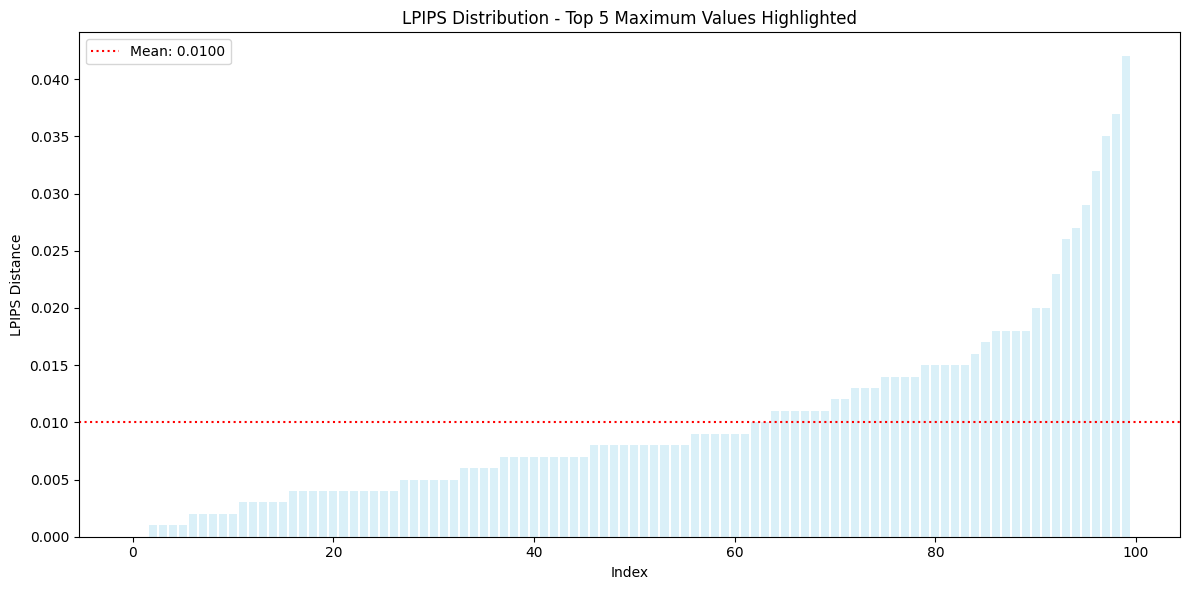

In [99]:
frequency_index=torch.argsort(frequency_distribution[:,1])
sorted_frequency_distribution=frequency_distribution[frequency_index]
plot_distribution(sorted_frequency_distribution/1000,k=0)

In [74]:
frequencies=frequency_distribution[:,1]

In [95]:
torch.sum(frequencies[:65])

tensor(504.)

In [36]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py --iteration=1

## For Corgi Dataset ## 

### Iteration 1 ###

In [19]:
original_images=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/image_tensor/original_image_tensor.pt')
generated_images=torch.load(f'/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/image_tensor/generated_images_1000_iteration1_python_inference_scipt.pt')
minimum_indices=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration1/lpips_minimum_indices.pt')
minimum_indices_way2=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration1/lpips_way_2_minimum_indices.pt')
frequency_distribution=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration1/frequency_distribution.pt')

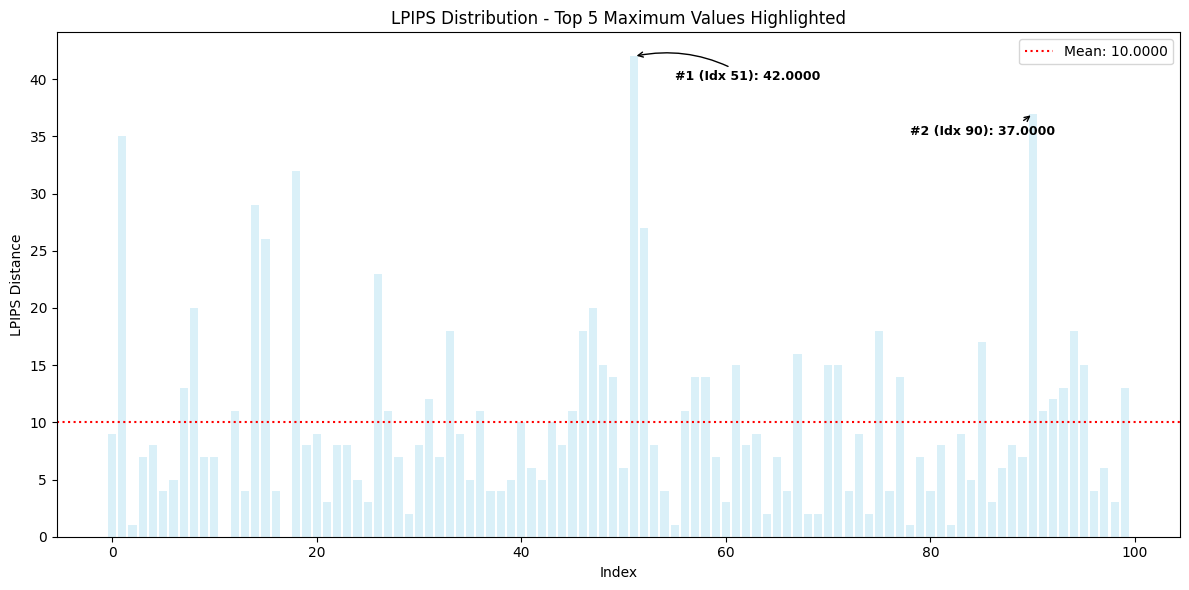

tensor([[11],
        [17]])


In [20]:
plot_distribution(frequency_distribution)
print(torch.argwhere(frequency_distribution[:,1]==0))

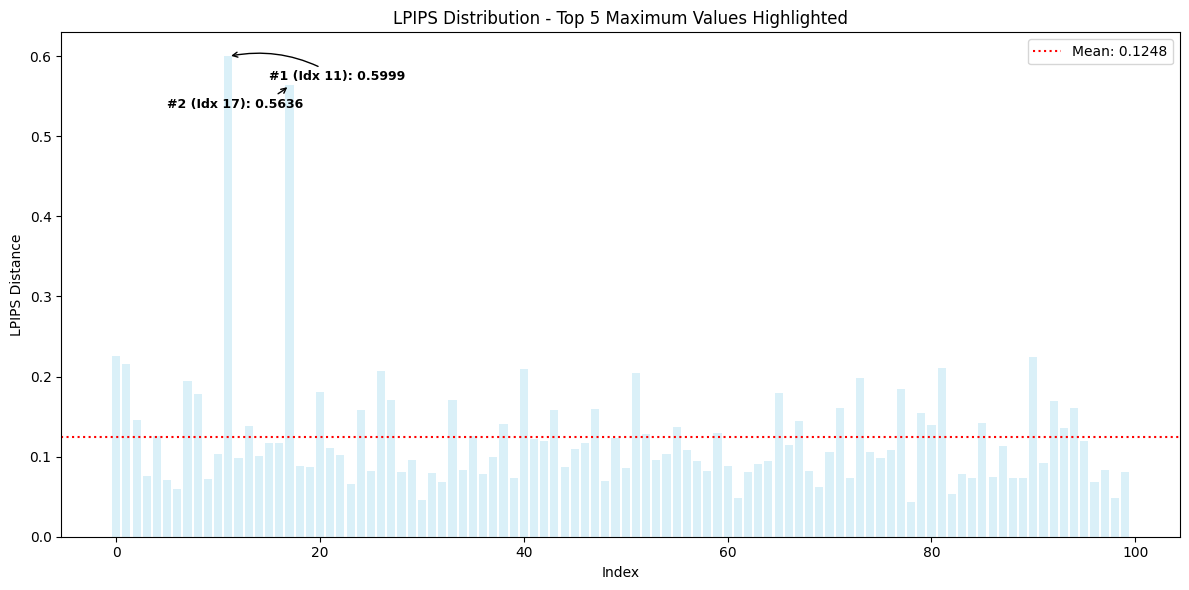

In [21]:
plot_distribution(minimum_indices)

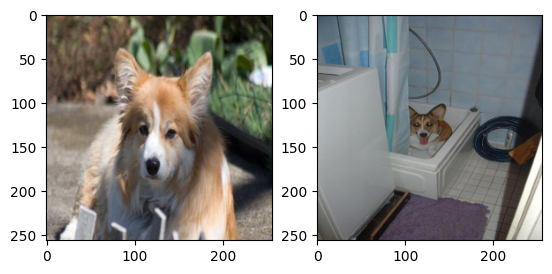

In [22]:
fig,ax=plt.subplots(1,2)

ax[0].imshow(image(original_images[11]))
ax[1].imshow(image(original_images[17]))
plt.show()

In [23]:
torch.sum(frequency_distribution[:,1])

tensor(1000.)

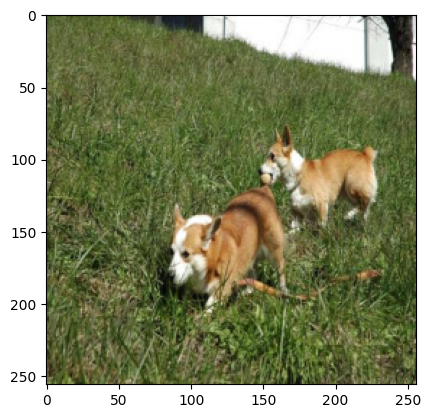

In [24]:
index=torch.topk(frequency_distribution[:,1],k=1)[1][0].item()
plt.imshow(image(original_images[index]))



In [25]:
frequency_sorted_indexes=torch.argsort(frequency_distribution[:,1])
out=frequency_distribution[frequency_sorted_indexes]
out

tensor([[17.,  0.],
        [11.,  0.],
        [ 2.,  1.],
        [55.,  1.],
        [82.,  1.],
        [78.,  1.],
        [68.,  2.],
        [69.,  2.],
        [29.,  2.],
        [64.,  2.],
        [74.,  2.],
        [21.,  3.],
        [25.,  3.],
        [60.,  3.],
        [98.,  3.],
        [86.,  3.],
        [37.,  4.],
        [38.,  4.],
        [66.,  4.],
        [54.,  4.],
        [80.,  4.],
        [72.,  4.],
        [ 5.,  4.],
        [16.,  4.],
        [76.,  4.],
        [96.,  4.],
        [13.,  4.],
        [84.,  5.],
        [42.,  5.],
        [39.,  5.],
        [35.,  5.],
        [ 6.,  5.],
        [24.,  5.],
        [87.,  6.],
        [41.,  6.],
        [97.,  6.],
        [50.,  6.],
        [65.,  7.],
        [32.,  7.],
        [89.,  7.],
        [28.,  7.],
        [10.,  7.],
        [ 9.,  7.],
        [ 3.,  7.],
        [79.,  7.],
        [59.,  7.],
        [53.,  8.],
        [62.,  8.],
        [ 4.,  8.],
        [81.,  8.],


In [26]:
torch.sum(out[:,1][-23:])

tensor(499.)

In [27]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py --iteration=3

Setting up LPIPS VGG...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
Calculating distances in batches of 100
100%|████████████████████████████████████████| 100/100 [04:58<00:00,  2.98s/it]
Done
Setting up [LPIPS] perceptual loss: t

In [28]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py --iteration=4

Setting up LPIPS VGG...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
Calculating distances in batches of 100
100%|████████████████████████████████████████| 100/100 [04:58<00:00,  2.98s/it]
Done
Setting up [LPIPS] perceptual loss: t

In [29]:
!python /home/saurabhg/SFU_research_internship/examples/images/cifar10/metric_distance.py --iteration=5

Setting up LPIPS VGG...
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/saurabhg/flow_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /home/saurabhg/flow_env/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
Calculating distances in batches of 100
100%|████████████████████████████████████████| 100/100 [04:58<00:00,  2.98s/it]
Done
Setting up [LPIPS] perceptual loss: t

In [ ]:
distribution1=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration1/frequency_distribution.pt')
distrubution1=distribution1/len(distribution1)
distribution2=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration2/frequency_distribution.pt')
distrubution2=distribution1/len(distribution2)
distribution3=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration3/frequency_distribution.pt')
distrubution3=distribution1/len(distribution3)
distribution4=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration4/frequency_distribution.pt')
distrubution4=distribution1/len(distribution4)
distribution5=torch.load('/home/saurabhg/scratch/corgi_dataset/flow_outputs/icfm/distances/iteration5/frequency_distribution.pt')
distrubution5=distribution1/len(distribution5)